# Exploratory Data Analysis (EDA)

The first step in any machine learning project is to understand the data.

In this notebook, we will:

- Inspect the dataset structure
- Explore the target variable
- Identify relationships between features and sale price
- Investigate missing values
- Highlight potential feature engineering opportunities


## Import libraries

First, import the libraries used throughout the analysis.

In [3]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

## Load the data

The competition provides separate training and test datasets. The training dataset contains the target variable (`SalePrice`), while the test dataset contains only the predictor variables.

We load both datasets, inspect their dimensions, check for duplicated rows, check column names etc.

In [4]:
df_test = pd.read_csv("data/test.csv")
df_train = pd.read_csv("data/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

1460 rows
0 duplicated rows
81 columns
--------------------
Test set:

1459 rows
0 duplicated rows
80 columns
--------------------
Columns train/test:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrB

In [5]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Understanding the target variable

Apart from the `SalePrice` column, which is missing from the `df_test` dataset, the other columns are all the same. The sale price is, of course, our target variable, i.e., the thing we will have to create a model to find out base on the other features.

Because this is a regression problem, the target variable deserves special attention. Let's inspect the distribution of house prices.

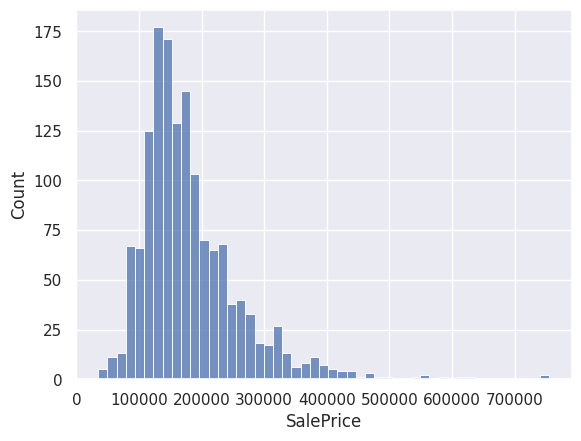

In [7]:
# Histogram
sns.histplot(df_train.get("SalePrice"))
plt.show()

As seen on the histogram above, the target feature `SalePrice` is right-skewed. In such cases, it is useful to perform a log transformation on this feature. After this transformation, the distribution closer resembles a normal distribution.

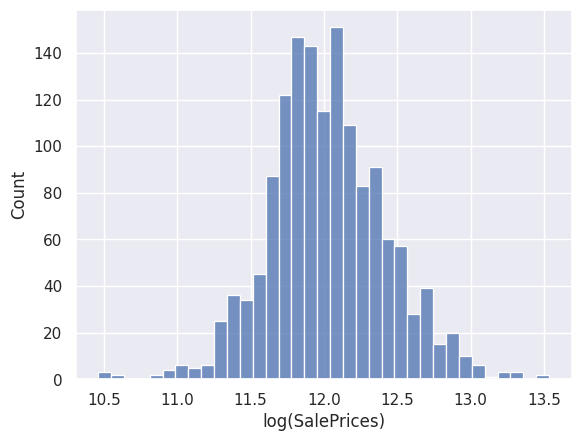

In [15]:
# Histogram log
sns.histplot(np.log1p(df_train.get("SalePrice")))
plt.xlabel("log(SalePrices)")
plt.show()

It is also useful to check for outliers in the house prices.

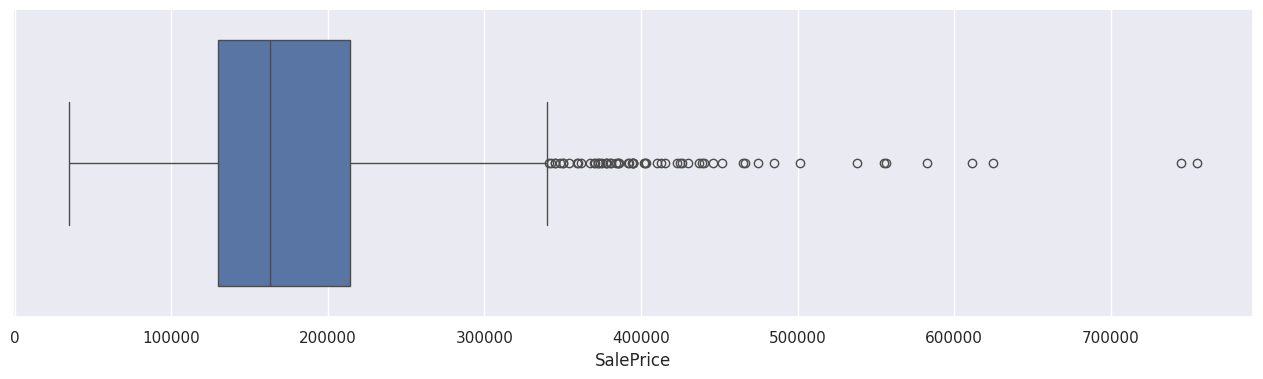

In [ ]:
# Boxplot
plt.figure(figsize=(16, 4))
sns.boxplot(df_train["SalePrice"], orient='h')
plt.xlabel("SalePrice")
plt.show()

There are outliers and we will have to deal with them later. Now let's go for the other features.

## Combining train and test data

Many preprocessing steps must be applied consistently to both datasets. For exploratory purposes, it is therefore useful to temporarily combine the predictor variables from the training and test sets into a single dataframe.

The target variable (`SalePrice`) is excluded because it is only available in the training data.

In [51]:
X_train = df_train.drop(columns="SalePrice")

df_full = pd.concat(
    [X_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test - target feature ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)


    Full dataset ( train + test - target feature ):

    2919 rows
    0 duplicated rows
    80 columns
    


In order to start getting a feel for the data we have in our hands, we can use `info()` and `describe()` to learn about data types, missing data, and overall statistical metrics such as mean, median, max, min etc. While trying to understand the data, it is also very helpful to look at the [`data_description.txt`](data/data_description.txt) file in the `data` directory of this repository.

In [ ]:
# Data types and Non-null counts
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [ ]:
# Statistics
df_full.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,...,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,...,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,...,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,...,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,...,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,...,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


## Histograms

As we did for the target variable, we can also look at the distributions for all numerical features.

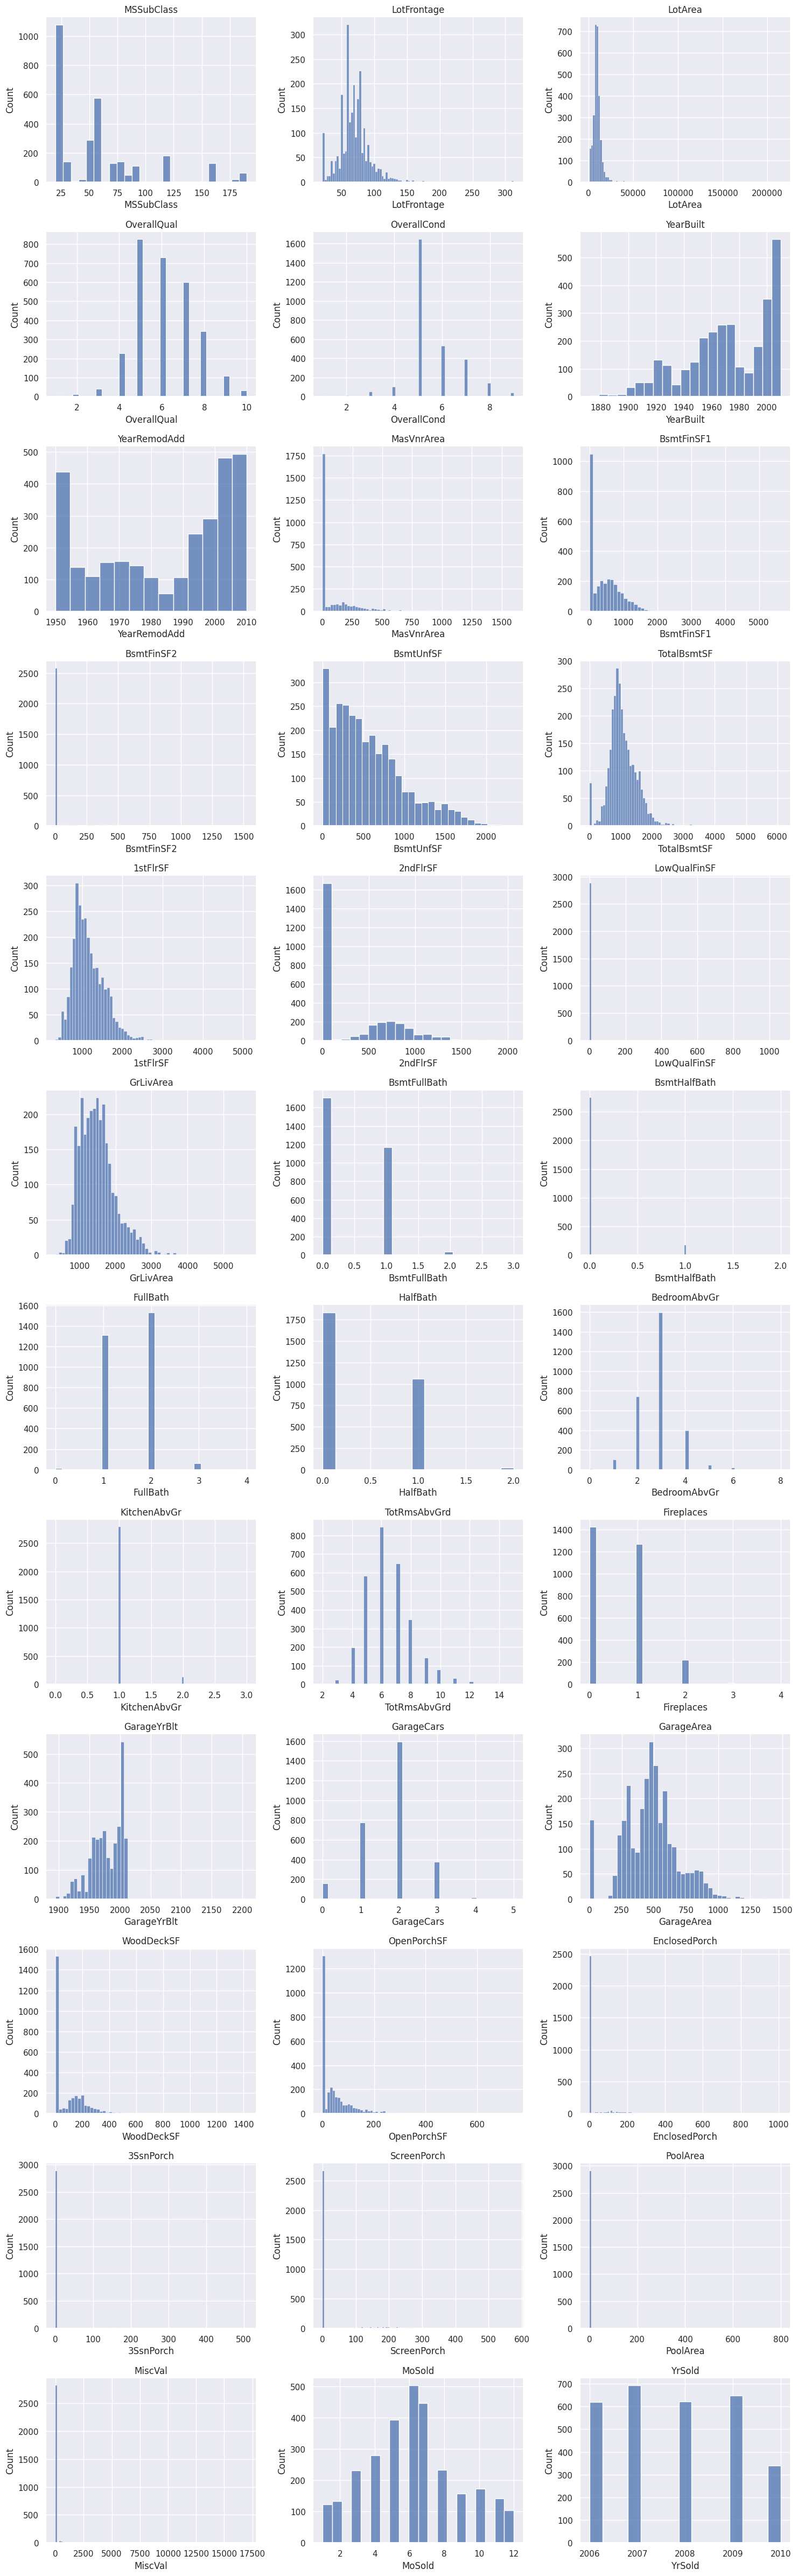

In [ ]:
# Separate numerical features
df_numerical = df_full.select_dtypes(exclude=['object'])
df_numerical = df_numerical.drop(["Id"], axis=1)

# Histograms for all features
cols = df_numerical.columns
n_cols = 3  # adjust as needed
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make it 1D for easy indexing

for i, col in enumerate(cols):
    sns.histplot(df_numerical[col], ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Outliers

As we did for `SalePrice`, we can check all numerical data for outliers.

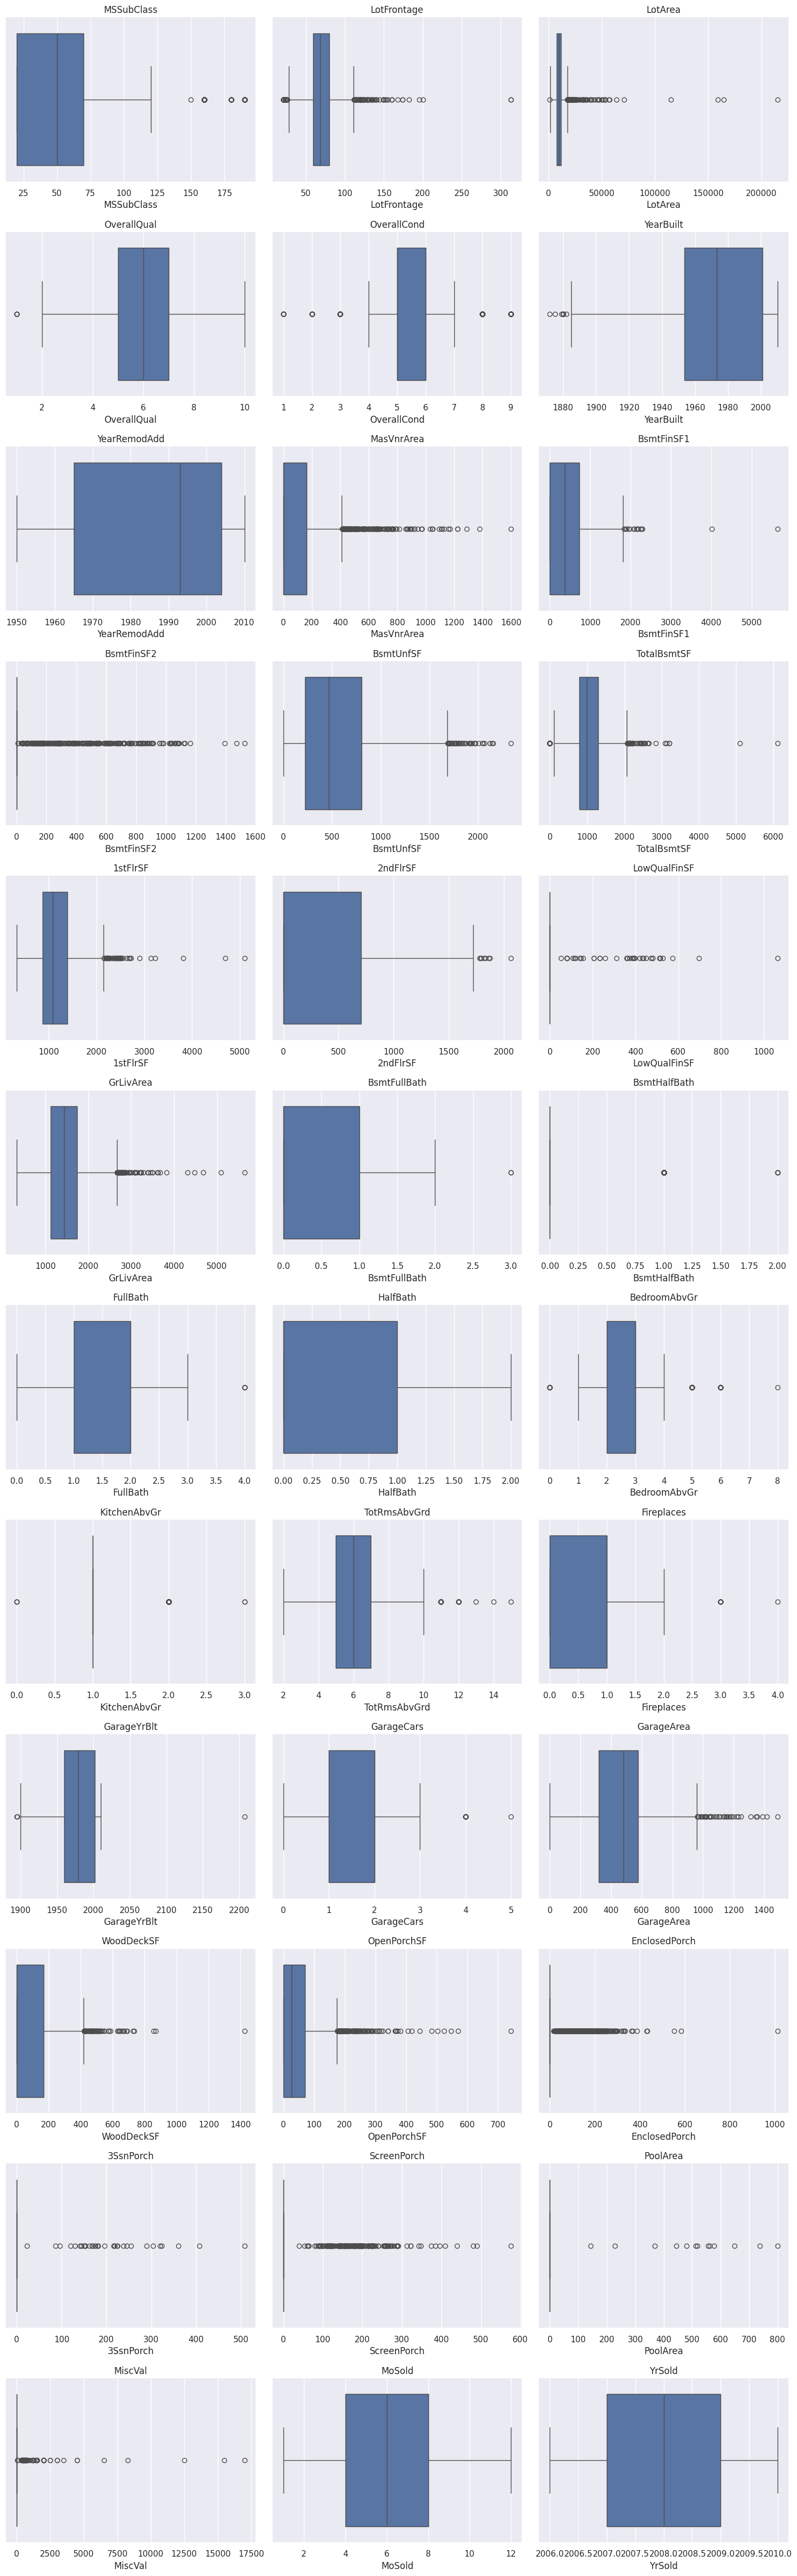

In [ ]:
# Boxplots for all features
cols = df_numerical.columns
n_cols = 3  # adjust as needed
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make it 1D for easy indexing

for i, col in enumerate(cols):
    sns.boxplot(df_numerical[col], ax=axes[i], orient="h")
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

From the images above and from the one we did for `SalePrice`, we see that there are outliers in the data. We will not delete the rows containing the outliers because by doing so we might lose some important information. The outliers will have to be handled later on the modeling stage.

## Missing Values

Missing data is one of the main challenges in this dataset.

Before deciding how to handle missing values, we first need to understand which features contain missing observations, how many values are missing, and whether missing values may carry information themselves.

We'll go through each feature to decide how to handle its missing values. As we proceed, we'll use the [`data_description.txt`](data/data_description.txt) to guide these decisions. For numerical features, fill in missing data with either 0 (which represents "None"), the mean, or the mode, whichever makes more sense. For categorical features, fill in the missing data with "None" if it seems appropriate; otherwise, fill it with the mode.

Let's start by listing all features in descending order by the amount of missing values.

In [ ]:
# All features with missing values
df_missing = df_full.isnull().sum().sort_values(ascending=False)
df_missing = df_missing.loc[df_missing.values > 0]
df_missing

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageQual       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF1         1
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior2nd        1
dtype: int64

It will be usefull to separate the categorical from the numerical data.

### Categorical features



In [100]:
# Only categorical features
categorical_columns = [column for column in df_full if column not in df_numerical]
df_missing_categorical = df_full[categorical_columns].isnull().sum().sort_values(ascending=False)
df_missing_categorical = df_missing_categorical.loc[df_missing_categorical.values > 0]
df_missing_categorical

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
GarageCond       159
GarageFinish     159
GarageQual       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MSZoning           4
Functional         2
Utilities          2
Exterior1st        1
Exterior2nd        1
KitchenQual        1
SaleType           1
Electrical         1
dtype: int64

In [112]:
# Unique values and value counts
for column in df_missing_categorical.index:
    print("-"*30)
    print(df_full[column].value_counts(dropna=False))
print("-"*30)

------------------------------
PoolQC
NaN    2909
Ex        4
Gd        4
Fa        2
Name: count, dtype: int64
------------------------------
MiscFeature
NaN     2814
Shed      95
Gar2       5
Othr       4
TenC       1
Name: count, dtype: int64
------------------------------
Alley
NaN     2721
Grvl     120
Pave      78
Name: count, dtype: int64
------------------------------
Fence
NaN      2348
MnPrv     329
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64
------------------------------
MasVnrType
NaN        1766
BrkFace     879
Stone       249
BrkCmn       25
Name: count, dtype: int64
------------------------------
FireplaceQu
NaN    1420
Gd      744
TA      592
Fa       74
Po       46
Ex       43
Name: count, dtype: int64
------------------------------
GarageCond
TA     2654
NaN     159
Fa       74
Gd       15
Po       14
Ex        3
Name: count, dtype: int64
------------------------------
GarageFinish
Unf    1230
RFn     811
Fin     719
NaN     159
Name: count, d

As we see, almost all of the data in `PoolQC` are missing. And from  we see this refers to "Pool Quality". This means most of the houses do not have a pool. This missing value actually carries helpfull information. The same happens for all the categorical features for which the [`data_description.txt`](data/data_description.txt) file say that `NA` stands for "None" or "This house does not have this item". For features of this type we fill `NA` values with the `str` value "None".

There are also features with a small amount of missing values and with an expressive mode, e.g. `SaleType` for which the vast majority is "WD". For thie category of feature we fill `NA` values with the mode.

Examples:

- `Exterior1st`: Exterior covering on house. It's reasonable to think all houses have at some kind of exterior covering. So, for the first material we fill the only missing value with the mode which is Vinyl Siding.
- `Exterior2nd`: Exterior covering on house (if more than one material). As it is possible that there is no second material for the exterior covering, we fill the only missing value with "None".


In [ ]:
# Fill with "None"
list_na_is_none = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageCond",
    "GarageFinish",
    "GarageQual",
    "GarageType",
    "BsmtCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtFinType2",
    "BsmtFinType1",
    "Exterior2nd",
]
for column in list_na_is_none:
    df_full[column] = df_full[column].fillna("None")

# Fill with the mode
list_na_is_mode = [
    "MSZoning",
    "Functional",
    "Utilities",
    "KitchenQual",
    "SaleType",
    "Electrical",
    "Exterior1st",
]
for column in list_na_is_mode:
    df_full[column] = df_full[column].fillna(df_full[column].mode()[0])


### Numerical features

In [107]:
# Only numerical features
numerical_columns = [column for column in df_numerical]
df_missing_numerical = df_full[numerical_columns].isnull().sum().sort_values(ascending=False)
df_missing_numerical = df_missing_numerical.loc[df_missing_numerical.values > 0]
df_missing_numerical

LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
GarageCars        1
BsmtFinSF2        1
GarageArea        1
TotalBsmtSF       1
BsmtFinSF1        1
BsmtUnfSF         1
dtype: int64

In [113]:
# Unique values and value counts
for column in df_missing_numerical.index:
    print("-"*30)
    print(df_full[column].value_counts(dropna=False))
print("-"*30)

------------------------------
LotFrontage
NaN      486
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
155.0      1
126.0      1
200.0      1
131.0      1
133.0      1
Name: count, Length: 129, dtype: int64
------------------------------
GarageYrBlt
NaN       159
2005.0    142
2006.0    115
2007.0    115
2004.0     99
         ... 
1896.0      1
1895.0      1
2207.0      1
1943.0      1
1919.0      1
Name: count, Length: 104, dtype: int64
------------------------------
MasVnrArea
0.0      1738
NaN        23
120.0      15
176.0      13
200.0      13
         ... 
355.0       1
405.0       1
327.0       1
257.0       1
382.0       1
Name: count, Length: 445, dtype: int64
------------------------------
BsmtFullBath
0.0    1705
1.0    1172
2.0      38
3.0       2
NaN       2
Name: count, dtype: int64
------------------------------
BsmtHalfBath
0.0    2742
1.0     171
2.0       4
NaN       2
Name: count, dtype: int64
------------------------------
GarageCars
2.0    1594
1.